In [27]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

DATA_RAW_PUBLIC = PROJECT_ROOT / "data" / "raw" / "public"
DATASET_DIR = PROJECT_ROOT / "data" / "sample"

activities_path = DATASET_DIR / "running_10k_synthetic_activities.csv"
athlete_summary_path = DATASET_DIR / "running_10k_synthetic_athlete_summary.csv"
data_dictionary_path = DATASET_DIR / "running_10k_synthetic_data_dictionary.csv"

activities_path = DATASET_DIR / "running_10k_synthetic_activities.csv"
athlete_summary_path = DATASET_DIR / "running_10k_synthetic_athlete_summary.csv"
data_dictionary_path = DATASET_DIR / "running_10k_synthetic_data_dictionary.csv"

In [23]:
activities = pd.read_csv(activities_path)
athlete_summary = pd.read_csv(athlete_summary_path)
data_dictionary = pd.read_csv(data_dictionary_path)

print("Activities shape:", activities.shape)
print("Athlete summary shape:", athlete_summary.shape)
print("Data dictionary shape:", data_dictionary.shape)

Activities shape: (4239, 34)
Athlete summary shape: (100, 27)
Data dictionary shape: (24, 4)


## Updated project objective

The objective of this project is to predict a runner's 10 km race finish time using the previous 3 months of training activity data.

The target variable is:

`race_10k_finish_time_min`

The first version of the project uses a realistic synthetic dataset because no suitable public dataset was found with all the required fields: activity history, heart rate, elevation, training duration, and 10 km race result.

The goal of this dataset is to build and test the full end-to-end machine learning pipeline before adapting the same workflow to real personal running data.

In [28]:
activities.head()

,activity_id,athlete_id,activity_date,week_number,days_before_race,activity_type,distance_km,duration_min,pace_min_per_km,avg_heart_rate,...,athlete_profile,training_scenario,sex,age,estimated_max_hr,source,race_10k_finish_time_min,race_10k_finish_time_seconds,race_10k_finish_time_hhmmss,race_10k_pace_min_per_km
0,ACT000001,A001,2026-01-07,1,89,easy_run,26.82,144.93,5.40,147,...,intermediate,progressive_build,M,22,180,synthetic_v1,45.89,2754.0,00:45:54,4.59
1,ACT000002,A001,2026-01-08,1,88,easy_run,7.93,41.09,5.18,133,...,intermediate,progressive_build,M,22,180,synthetic_v1,45.89,2754.0,00:45:54,4.59
2,ACT000003,A001,2026-01-11,1,85,easy_run,13.55,74.33,5.49,132,...,intermediate,progressive_build,M,22,180,synthetic_v1,45.89,2754.0,00:45:54,4.59
3,ACT000004,A001,2026-01-12,2,84,interval_run,20.50,97.94,4.78,163,...,intermediate,progressive_build,M,22,180,synthetic_v1,45.89,2754.0,00:45:54,4.59
4,ACT000005,A001,2026-01-14,2,82,easy_run,7.84,42.45,5.41,129,...,intermediate,progressive_build,M,22,180,synthetic_v1,45.89,2754.0,00:45:54,4.59


In [29]:
activities.columns.tolist()

['activity_id',
 'athlete_id',
 'activity_date',
 'week_number',
 'days_before_race',
 'activity_type',
 'distance_km',
 'duration_min',
 'pace_min_per_km',
 'avg_heart_rate',
 'max_heart_rate',
 'elevation_gain_m',
 'calories',
 'weekly_km',
 'weekly_duration_min',
 'weekly_run_count',
 'weekly_avg_pace',
 'weekly_avg_hr',
 'weekly_elevation_gain_m',
 'longest_run_km',
 'rolling_4w_km',
 'avg_weekly_km_last_4w',
 'active_weeks_last_4w',
 'rolling_4w_duration_min',
 'athlete_profile',
 'training_scenario',
 'sex',
 'age',
 'estimated_max_hr',
 'source',
 'race_10k_finish_time_min',
 'race_10k_finish_time_seconds',
 'race_10k_finish_time_hhmmss',
 'race_10k_pace_min_per_km']

In [30]:
activities.info()

<class 'pandas.DataFrame'>
RangeIndex: 4239 entries, 0 to 4238
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   activity_id                   4239 non-null   str    
 1   athlete_id                    4239 non-null   str    
 2   activity_date                 4239 non-null   str    
 3   week_number                   4239 non-null   int64  
 4   days_before_race              4239 non-null   int64  
 5   activity_type                 4239 non-null   str    
 6   distance_km                   4239 non-null   float64
 7   duration_min                  4239 non-null   float64
 8   pace_min_per_km               4239 non-null   float64
 9   avg_heart_rate                4239 non-null   int64  
 10  max_heart_rate                4239 non-null   int64  
 11  elevation_gain_m              4239 non-null   float64
 12  calories                      4239 non-null   int64  
 13  weekly_km     

In [31]:
activities.isna().mean().sort_values(ascending=False).head(20)

activity_id                0.0
athlete_id                 0.0
activity_date              0.0
week_number                0.0
days_before_race           0.0
activity_type              0.0
distance_km                0.0
duration_min               0.0
pace_min_per_km            0.0
avg_heart_rate             0.0
max_heart_rate             0.0
elevation_gain_m           0.0
calories                   0.0
weekly_km                  0.0
weekly_duration_min        0.0
weekly_run_count           0.0
weekly_avg_pace            0.0
weekly_avg_hr              0.0
weekly_elevation_gain_m    0.0
longest_run_km             0.0
dtype: float64

In [32]:
athlete_summary.head()

,athlete_id,athlete_profile,training_scenario,sex,age,estimated_max_hr,total_3month_km,total_3month_duration_min,total_runs,avg_training_pace_min_per_km,...,avg_weekly_runs_last_4w,base_weekly_km_plan,typical_runs_per_week_plan,base_10k_race_pace_min_per_km,consistency_trait,hr_efficiency_factor,race_10k_pace_min_per_km,race_10k_finish_time_min,race_10k_finish_time_seconds,race_10k_finish_time_hhmmss
0,A001,intermediate,progressive_build,M,22,180,717.05,3768.59,56,5.255919,...,5.00,57.4,4,4.83,0.726,1.044,4.59,45.89,2754.0,00:45:54
1,A002,beginner,minor_injury,F,44,170,125.89,1002.77,18,7.966503,...,1.25,13.5,2,7.02,0.805,0.938,7.30,72.95,4377.0,01:12:57
2,A003,beginner,minor_injury,M,43,172,233.82,1920.37,16,8.211779,...,1.00,21.7,1,7.07,0.980,0.931,7.16,71.59,4295.0,01:11:35
3,A004,recreational,progressive_build,M,36,180,486.33,2969.38,40,6.106572,...,3.50,36.8,3,5.36,0.980,0.960,5.23,52.31,3138.0,00:52:18
4,A005,recreational,progressive_build,M,40,174,463.98,2783.30,34,5.998645,...,3.25,36.3,3,5.30,0.866,1.029,5.12,51.15,3069.0,00:51:09


In [33]:
athlete_summary.columns.tolist()

['athlete_id',
 'athlete_profile',
 'training_scenario',
 'sex',
 'age',
 'estimated_max_hr',
 'total_3month_km',
 'total_3month_duration_min',
 'total_runs',
 'avg_training_pace_min_per_km',
 'avg_heart_rate',
 'max_heart_rate_observed',
 'total_elevation_gain_m',
 'longest_run_km',
 'last_4w_km',
 'avg_weekly_km_last_4w',
 'active_weeks_last_4w',
 'avg_weekly_runs_last_4w',
 'base_weekly_km_plan',
 'typical_runs_per_week_plan',
 'base_10k_race_pace_min_per_km',
 'consistency_trait',
 'hr_efficiency_factor',
 'race_10k_pace_min_per_km',
 'race_10k_finish_time_min',
 'race_10k_finish_time_seconds',
 'race_10k_finish_time_hhmmss']

In [34]:
athlete_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100.0,37.570000,9.029978,19.000000,30.750000,38.000000,44.250000,58.000000
estimated_max_hr,100.0,180.970000,8.735687,161.000000,174.000000,181.000000,186.250000,203.000000
total_3month_km,100.0,473.998900,303.296625,94.150000,251.097500,422.125000,679.832500,1463.700000
total_3month_duration_min,100.0,2454.309400,1073.313896,693.550000,1700.577500,2362.475000,3216.027500,5612.880000
total_runs,100.0,42.390000,19.080846,12.000000,26.750000,40.000000,57.500000,87.000000
avg_training_pace_min_per_km,100.0,5.908943,1.313109,3.427774,4.838379,6.010956,6.749212,8.504601
avg_heart_rate,100.0,134.176420,11.055010,112.722222,126.775000,133.175556,141.173944,163.984848
max_heart_rate_observed,100.0,173.810000,13.761823,141.000000,167.500000,175.000000,181.250000,202.000000
total_elevation_gain_m,100.0,3920.601000,2828.506396,540.900000,1804.450000,3048.100000,5231.550000,13823.300000
longest_run_km,100.0,24.969000,9.851985,7.390000,17.102500,24.585000,30.762500,57.400000


In [35]:
athlete_summary["race_10k_finish_time_min"].describe()

count    100.000000
mean      51.507000
std       11.509385
min       30.100000
25%       42.685000
50%       51.420000
75%       59.530000
max       73.310000
Name: race_10k_finish_time_min, dtype: float64

In [36]:
athlete_summary.groupby("athlete_profile")["race_10k_finish_time_min"].agg(
    ["count", "min", "mean", "max"]
).sort_values("mean")

,count,min,mean,max
athlete_profile,,,,
elite,4,30.10,31.890000,34.21
advanced,18,34.50,38.201111,43.15
intermediate,24,40.50,44.901250,51.50
recreational,29,49.62,54.510345,59.40
beginner,25,59.92,67.083600,73.31


In [37]:
athlete_summary.groupby("athlete_profile")[
    ["total_3month_km", "avg_training_pace_min_per_km", "avg_heart_rate", "total_elevation_gain_m", "race_10k_finish_time_min"]
].mean().sort_values("race_10k_finish_time_min")

,total_3month_km,avg_training_pace_min_per_km,avg_heart_rate,total_elevation_gain_m,race_10k_finish_time_min
athlete_profile,,,,,
elite,1357.527500,3.667240,150.085567,12190.450000,31.890000
advanced,820.950000,4.363974,144.317791,7270.127778,38.201111
intermediate,560.307917,5.132662,136.517071,4606.091667,44.901250
recreational,332.676897,6.283806,130.567936,2508.906897,54.510345
beginner,163.906400,7.690380,126.267985,1165.260000,67.083600


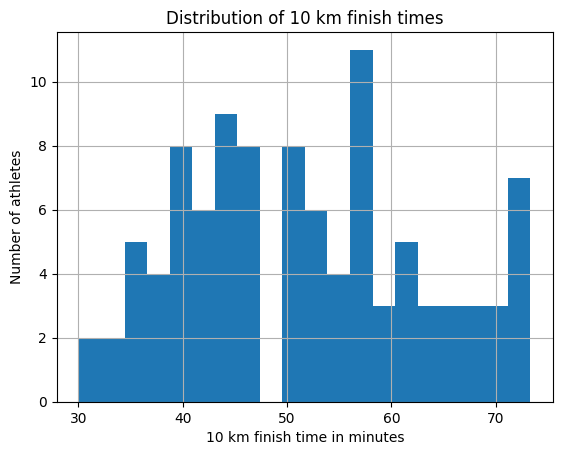

In [38]:
athlete_summary["race_10k_finish_time_min"].hist(bins=20)

plt.xlabel("10 km finish time in minutes")
plt.ylabel("Number of athletes")
plt.title("Distribution of 10 km finish times")
plt.show()

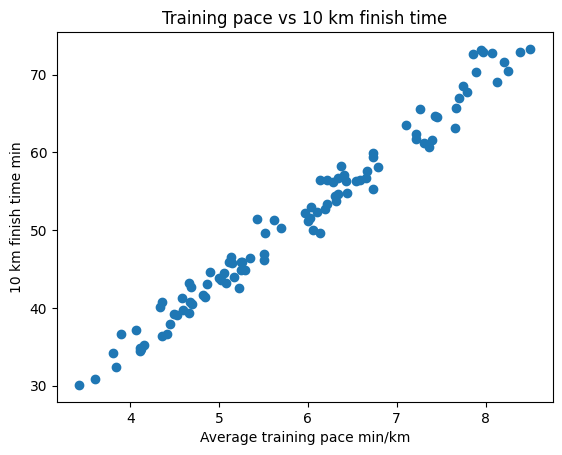

In [39]:
plt.scatter(
    athlete_summary["avg_training_pace_min_per_km"],
    athlete_summary["race_10k_finish_time_min"]
)

plt.xlabel("Average training pace min/km")
plt.ylabel("10 km finish time min")
plt.title("Training pace vs 10 km finish time")
plt.show()

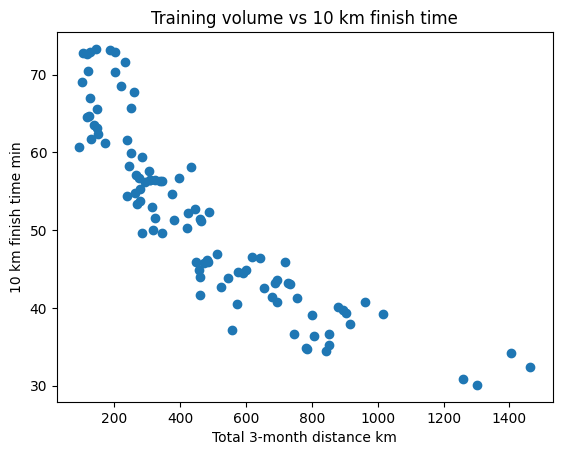

In [40]:
plt.scatter(
    athlete_summary["total_3month_km"],
    athlete_summary["race_10k_finish_time_min"]
)

plt.xlabel("Total 3-month distance km")
plt.ylabel("10 km finish time min")
plt.title("Training volume vs 10 km finish time")
plt.show()

## Initial exploration conclusion

The synthetic 10 km dataset was loaded successfully.

Initial observations:

- Number of activities: 4 239
- Number of athletes: 100
- Target variable: race_10k_finish_time_min
- Main useful features: 'total_3month_km', 'total_3month_duration_min', 'total_runs', 'avg_training_pace_min_per_km', 'avg_heart_rate', 'longest_run_km', 'last_4w_km', 'avg_weekly_km_last_4w', 'active_weeks_last_4w', 'avg_weekly_runs_last_4w', 'base_weekly_km_plan', 'typical_runs_per_week_plan',
- Missing values: No
- First signs of coherence:
- Potential limitations: 

The dataset appears suitable for the first version of the project because it contains one row per activity and an athlete-level summary table with the 10 km race finish time target.

## Week 1 exploration summary

During Week 1, I set up the project repository, created the Python environment, prepared the notebook structure, and selected the dataset for the first version of the project.

The final project objective is:

**Predict a runner's 10 km race finish time from the previous 3 months of training data.**

The target variable is:

`race_10k_finish_time_min`

I decided to use a realistic synthetic dataset because I could not find a suitable public dataset containing all the required information:

- activity history
- weekly/monthly training volume
- duration
- pace
- heart rate
- elevation
- 10 km race result

The synthetic dataset allows me to build the full end-to-end ML pipeline while keeping the data coherent with realistic running behavior.

The dataset contains:

- one row per activity in the activity-level file
- one row per athlete in the athlete-level summary file
- 100 athletes
- 13 weeks of training
- realistic athlete profiles from beginner to elite

The first model will use the athlete-level summary dataset because it already contains one row per athlete and the target variable.

## First useful features for modeling

For the first baseline model, I will start with simple athlete-level features:

- total_3month_km
- avg_training_pace_min_per_km
- avg_heart_rate
- total_elevation_gain_m
- longest_run_km
- last_4w_km
- avg_weekly_km_last_4w
- active_weeks_last_4w
- avg_weekly_runs_last_4w

The target variable will be:

- race_10k_finish_time_min

This first version will keep the modeling problem simple before creating more advanced features from the activity-level data.

In [ ]:
target_column = "race_10k_finish_time_min"

candidate_features = [
    "total_3month_km",
    "avg_training_pace_min_per_km",
    "avg_heart_rate",
    "total_elevation_gain_m",
    "longest_run_km",
    "last_4w_km",
    "avg_weekly_km_last_4w",
    "active_weeks_last_4w",
    "avg_weekly_runs_last_4w",
]

model_preview = athlete_summary[candidate_features + [target_column]]

model_preview.head()

,total_3month_km,avg_training_pace_min_per_km,avg_heart_rate,total_elevation_gain_m,longest_run_km,last_4w_km,avg_weekly_km_last_4w,active_weeks_last_4w,avg_weekly_runs_last_4w,race_10k_finish_time_min
0,717.05,5.255919,142.232143,5051.4,33.76,257.50,64.3750,4,5.00,45.89
1,125.89,7.966503,115.555556,952.3,14.28,40.44,10.1100,4,1.25,72.95
2,233.82,8.211779,114.937500,1444.3,25.68,73.91,18.4775,4,1.00,71.59
3,486.33,6.106572,126.225000,2685.4,26.86,173.24,43.3100,4,3.50,52.31
4,463.98,5.998645,128.823529,3356.3,33.36,171.51,42.8775,4,3.25,51.15


In [42]:
model_preview.describe().T

,count,mean,std,min,25%,50%,75%,max
total_3month_km,100.0,473.998900,303.296625,94.150000,251.097500,422.125000,679.832500,1463.700000
avg_training_pace_min_per_km,100.0,5.908943,1.313109,3.427774,4.838379,6.010956,6.749212,8.504601
avg_heart_rate,100.0,134.176420,11.055010,112.722222,126.775000,133.175556,141.173944,163.984848
total_elevation_gain_m,100.0,3920.601000,2828.506396,540.900000,1804.450000,3048.100000,5231.550000,13823.300000
longest_run_km,100.0,24.969000,9.851985,7.390000,17.102500,24.585000,30.762500,57.400000
last_4w_km,100.0,159.582100,104.594686,20.500000,78.530000,145.115000,216.660000,506.180000
avg_weekly_km_last_4w,100.0,39.895525,26.148671,5.125000,19.632500,36.278750,54.165000,126.545000
active_weeks_last_4w,100.0,4.000000,0.000000,4.000000,4.000000,4.000000,4.000000,4.000000
avg_weekly_runs_last_4w,100.0,3.457500,1.613960,1.000000,2.250000,3.250000,4.750000,7.000000
race_10k_finish_time_min,100.0,51.507000,11.509385,30.100000,42.685000,51.420000,59.530000,73.310000


In [43]:
correlations = (
    model_preview
    .corr(numeric_only=True)[target_column]
    .sort_values()
)

correlations

total_3month_km                -0.877902
avg_weekly_runs_last_4w        -0.864407
total_elevation_gain_m         -0.863798
last_4w_km                     -0.861976
avg_weekly_km_last_4w          -0.861976
longest_run_km                 -0.700680
avg_heart_rate                 -0.590418
avg_training_pace_min_per_km    0.988697
race_10k_finish_time_min        1.000000
active_weeks_last_4w                 NaN
Name: race_10k_finish_time_min, dtype: float64

In [44]:
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

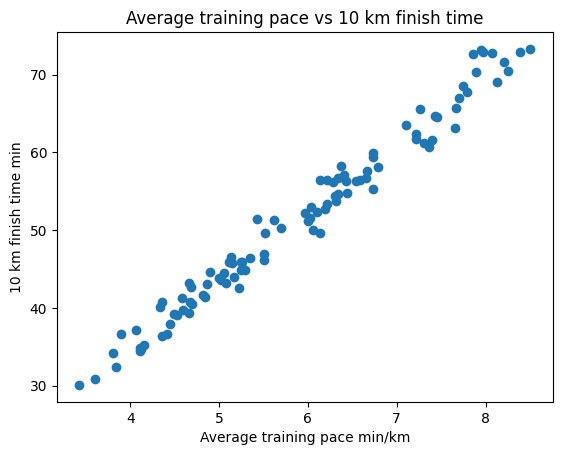

In [45]:
plt.scatter(
    athlete_summary["avg_training_pace_min_per_km"],
    athlete_summary["race_10k_finish_time_min"]
)

plt.xlabel("Average training pace min/km")
plt.ylabel("10 km finish time min")
plt.title("Average training pace vs 10 km finish time")

plt.savefig(FIGURES_DIR / "training_pace_vs_10k_finish_time.png", dpi=150, bbox_inches="tight")
plt.show()